# Patient-Calibrated 5-Stage XGBoost (v4 - Publishable)

**Overview: The Patient-Calibrated Paradigm**

This notebook evaluates a patient-calibrated XGBoost pipeline for classifying 5 sleep stages (Wake, N1, N2, N3, REM) using exclusively wrist accelerometer data.

**Modality Context**: Wrist accelerometry is non-invasive and suitable for ambulatory use, contrasting with polysomnography (PSG). The 5-stage classification task is inherently harder than 3-stage due to N1/N2/N3 granularity.

**v4 Publishability Improvements**:
- **Nested fold-aware threshold selection**: REM×N3 thresholds for fold k are tuned exclusively on the remaining 4 folds' OOF data — eliminating post-hoc optimization bias
- **ZeroR majority-class baseline**: Contextualizes all reported metrics against a trivial benchmark
- **Bootstrap 95% confidence intervals**: n=1,000 resamples for macro F1 and Cohen's Kappa
- **McNemar's test**: Pairwise statistical significance vs. ZeroR baseline
- **Conditional bout enforcement**: Applied only when it improves OOF macro F1
- **`safe_corr` defined outside loop**: Prevents ~25,000 redundant function redefinitions

In [1]:
!pip install -q xgboost statsmodels

## 1. Unzip and Load Data

### Subtask: Raw Data Extraction and Ingestion

This module handles the extraction and ingestion of the raw dataset. We systematically load the high-frequency wrist actigraphy (accelerometer x, y, z) and the corresponding Polysomnography (PSG) labels into isolated Pandas DataFrames. Critically, we intentionally exclude all photoplethysmography (heart rate) data files.

In [2]:
import zipfile
import os
import pandas as pd

# --- 1.A Dataset Extraction ---
zip_path = '/content/heartratedata.zip'
extract_path = '/content/heartratedata/'
if not os.path.exists(zip_path):
    zip_path = r'C:\Users\Ben\OneDrive\Documents\GitHub\Sleep-Time-Model\heartratedata.zip'
    extract_path = r'C:\Users\Ben\OneDrive\Documents\GitHub\Sleep-Time-Model\heartratedata'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("Extraction skipped: folder already exists.")

base_path = os.path.join(extract_path, 'motion-and-heart-rate-from-a-wrist-worn-wearable-and-labeled-sleep-from-polysomnography-1.0.0')
motion_dir = os.path.join(base_path, 'motion')
labels_dir = os.path.join(base_path, 'labels')

motion_list = []
labels_list = []
subject_ids = []

if os.path.exists(motion_dir):
    for filename in os.listdir(motion_dir):
        if filename.endswith('_acceleration.txt'):
            subject_id = filename.split('_')[0]
            subject_ids.append(subject_id)

subject_ids = sorted(subject_ids)
print(f"Discovered {len(subject_ids)} individual subjects.")

for subject_id in subject_ids:
    motion_file = os.path.join(motion_dir, f"{subject_id}_acceleration.txt")
    if os.path.exists(motion_file):
        try:
            df_m = pd.read_csv(motion_file, sep=' ', header=None, names=['timestamp', 'x', 'y', 'z'])
            df_m['subject_id'] = subject_id
            motion_list.append(df_m)
        except Exception as e:
            print(f"Error reading motion file for {subject_id}: {e}")

    label_file = os.path.join(labels_dir, f"{subject_id}_labeled_sleep.txt")
    if os.path.exists(label_file):
        try:
            df_l = pd.read_csv(label_file, sep=' ', header=None, names=['timestamp', 'label'])
            df_l['subject_id'] = subject_id
            labels_list.append(df_l)
        except Exception as e:
            print(f"Error reading label file for {subject_id}: {e}")

if motion_list:
    motion_df = pd.concat(motion_list, ignore_index=True)
    print("Motion Data successfully loaded into memory.")
else:
    raise ValueError("Critical Error: No Motion Data Found.")

if labels_list:
    labels_df = pd.concat(labels_list, ignore_index=True)
    print("PSG Labels successfully loaded into memory.")
else:
    raise ValueError("Critical Error: No Labels Data Found.")

# --- 1.E Clip pre-sleep motion data ---
motion_df['timestamp']  = motion_df['timestamp'].astype(float)
motion_df['subject_id'] = motion_df['subject_id'].astype(str)
labels_df['timestamp']  = labels_df['timestamp'].astype(float)
labels_df['subject_id'] = labels_df['subject_id'].astype(str)
label_start = labels_df.groupby('subject_id')['timestamp'].min().rename('label_start')
motion_df = motion_df.join(label_start, on='subject_id')
motion_df = motion_df[motion_df['timestamp'] >= motion_df['label_start'] - 30].copy()
motion_df.drop(columns='label_start', inplace=True)
print(f"Motion rows after pre-sleep clip: {len(motion_df):,}")

Extraction skipped: folder already exists.
Discovered 31 individual subjects.
Error reading motion file for 9106476: Unable to allocate 1.00 MiB for an array with shape (131072,) and data type int64
Error reading motion file for 9618981: Unable to allocate 1.00 MiB for an array with shape (131072,) and data type int64
Error reading motion file for 9961348: Unable to allocate 1.00 MiB for an array with shape (131072,) and data type int64


MemoryError: Unable to allocate 1.18 GiB for an array with shape (4, 39489817) and data type float64

## 2. Data Synchronization and Label Processing

### Subtask: Temporal Alignment and 5-Stage Classification

High-frequency raw motion data cannot be directly trained against 30-second sleep epoch labels. This section standardizes the dataset by casting timestamps to compatible formats and employing a backward-filling merge_asof function with a 30-second tolerance guard. The full 5-stage clinical architecture (Wake, N1, N2, N3, REM) is preserved for maximum diagnostic resolution.

In [3]:
label_map = {
    0: 'Wake',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    5: 'REM'
}

labels_df = labels_df[labels_df['label'].isin(label_map.keys())].copy()
labels_df['sleep_stage'] = labels_df['label'].map(label_map)

labels_df['timestamp'] = labels_df['timestamp'].astype(float)
motion_df['subject_id'] = motion_df['subject_id'].astype(str)
labels_df['subject_id'] = labels_df['subject_id'].astype(str)

motion_df = motion_df.sort_values(by='timestamp').reset_index(drop=True)
labels_df = labels_df.sort_values(by='timestamp').reset_index(drop=True)

merged_df = pd.merge_asof(motion_df, labels_df, on='timestamp', by='subject_id',
                           direction='backward', tolerance=30)

merged_df = merged_df.dropna(subset=['sleep_stage'])

print("Class Distribution in Synchronized Dataset:")
print(merged_df['sleep_stage'].value_counts())

## 3. Time-Series Feature Engineering

### Subtask: Contextualizing Motion Data

Accelerometers suffer from the "Stillness Paradox" where REM and NREM stages can present identical instantaneous physical profiles. To address this, we engineer macro-temporal context with rolling windows at 2, 5, 10, and 20 minute scales, allowing the model to recognize sedentary streaks and longer-term activity patterns that distinguish sleep stages.

In [4]:
import numpy as np

# --- 3.A Per-Sample Feature Precomputation ---
merged_df['epoch_start'] = (merged_df['timestamp'] // 30) * 30
merged_df['vm'] = np.sqrt(merged_df['x']**2 + merged_df['y']**2 + merged_df['z']**2)
merged_df['tilt_angle'] = np.arctan2(merged_df['z'],
                          np.sqrt(merged_df['x']**2 + merged_df['y']**2))

# --- 3.B Base Epoch Aggregation ---
epoch_df = merged_df.groupby(['subject_id', 'epoch_start']).agg(
    mean_vm=('vm', 'mean'),
    std_vm=('vm', 'std'),
    max_vm=('vm', 'max'),
    range_vm=('vm', lambda x: x.max() - x.min()),
    mean_tilt=('tilt_angle', 'mean'),
    std_tilt=('tilt_angle', 'std'),
    sleep_stage=('sleep_stage', 'first')
).reset_index()

# --- 3.C Spectral Features + ZCR + Inter-Axis Correlations + Spectral Ratios ---
print("Computing spectral + inter-axis + ratio features per epoch...")

def safe_corr(a, b):
    if len(a) < 2: return 0.0
    sa, sb = a.std(), b.std()
    if sa == 0 or sb == 0: return 0.0
    return float(np.corrcoef(a, b)[0, 1])

records = []
for (sid, es), group in merged_df.groupby(['subject_id', 'epoch_start']):
    vm = group['vm'].values
    x_vals, y_vals, z_vals = group['x'].values, group['y'].values, group['z'].values
    n = len(vm)
    row = {'subject_id': sid, 'epoch_start': es}
    if n >= 8:
        fs = n / 30.0
        fft_vals = np.abs(np.fft.rfft(vm))
        freqs = np.fft.rfftfreq(n, d=1.0 / fs)
        fft_norm = fft_vals / (fft_vals.sum() + 1e-10)
        row['spectral_entropy'] = float(-np.sum(fft_norm * np.log(fft_norm + 1e-10)))
        row['dominant_freq'] = float(freqs[np.argmax(fft_vals[1:]) + 1]) if len(fft_vals) > 1 else 0.0
        row['power_low']  = float(fft_vals[(freqs >= 0.3) & (freqs < 1.0)].sum())
        row['power_high'] = float(fft_vals[(freqs >= 1.0) & (freqs < 3.0)].sum())
        row['power_ratio'] = row['power_high'] / (row['power_low'] + 1e-10)
        row['total_power'] = row['power_low'] + row['power_high']
        vm_c = vm - vm.mean()
        row['zcr'] = float(np.sum(np.diff(np.sign(vm_c)) != 0) / n)
    else:
        row.update({'spectral_entropy': 0.0, 'dominant_freq': 0.0,
                    'power_low': 0.0, 'power_high': 0.0, 'zcr': 0.0,
                    'power_ratio': 0.0, 'total_power': 0.0})
    row['xy_corr'] = safe_corr(x_vals, y_vals)
    row['xz_corr'] = safe_corr(x_vals, z_vals)
    row['yz_corr'] = safe_corr(y_vals, z_vals)
    records.append(row)
extra_df = pd.DataFrame(records)
epoch_df = epoch_df.merge(extra_df, on=['subject_id', 'epoch_start'], how='left')
print(f"Extra features computed. Epoch count: {len(epoch_df):,}")

# --- 3.D Multi-Scale Rolling Windows (2m, 5m, 15m, 30m) ---
epoch_df = epoch_df.sort_values(by=['subject_id', 'epoch_start'])
for window, label in [(4, '2m'), (10, '5m'), (30, '15m'), (60, '30m')]:
    epoch_df[f'roll_mean_vm_{label}'] = epoch_df.groupby('subject_id')['mean_vm'].transform(
        lambda x, w=window: x.rolling(window=w, min_periods=1).mean()
    )
    # Rolling mean of epoch-level std_vm (smoothed variability over time)
    epoch_df[f'roll_mean_std_vm_{label}'] = epoch_df.groupby('subject_id')['std_vm'].transform(
        lambda x, w=window: x.rolling(window=w, min_periods=1).mean()
    )

# --- 3.E Circadian and Temporal Delta Features ---
epoch_df['time_of_night_hours'] = (
    epoch_df.groupby('subject_id')['epoch_start']
    .transform(lambda x: (x - x.min()) / 3600.0)
)
epoch_df['vm_delta']   = epoch_df.groupby('subject_id')['mean_vm'].diff().fillna(0)
epoch_df['vm_delta_2'] = epoch_df.groupby('subject_id')['mean_vm'].diff(2).fillna(0)

# --- 3.F Dynamic Rest-Activity Thresholding ---
baseline = epoch_df.groupby('subject_id')['mean_vm'].transform(lambda x: x.quantile(0.05))
epoch_df['is_movement'] = epoch_df['mean_vm'] > (baseline + 0.05)
epoch_df['last_movement_time'] = (
    epoch_df['epoch_start'].where(epoch_df['is_movement'])
    .groupby(epoch_df['subject_id']).ffill()
)
epoch_df['time_since_last_movement'] = (
    epoch_df['epoch_start'] - epoch_df['last_movement_time'].fillna(epoch_df['epoch_start'])
)
epoch_df.drop(columns=['is_movement', 'last_movement_time'], inplace=True)

# --- 3.G Fill NaN values ---
epoch_df.columns = epoch_df.columns.astype(str)
epoch_df['std_vm'] = epoch_df['std_vm'].fillna(0)
epoch_df['time_since_last_movement'] = epoch_df['time_since_last_movement'].ffill().fillna(0)
for col in [c for c in epoch_df.columns if c.startswith('roll_')]:
    epoch_df[col] = epoch_df[col].fillna(0)
for col in ['xy_corr', 'xz_corr', 'yz_corr',
            'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'zcr',
            'mean_tilt', 'std_tilt', 'power_ratio', 'total_power']:
    if col in epoch_df.columns:
        epoch_df[col] = epoch_df[col].fillna(0)

# --- 3.H Subject-Normalized Z-Score Features ---
print("Computing subject-normalized z-score features...")
motion_features_to_norm = ['mean_vm', 'std_vm', 'max_vm', 'range_vm',
                            'spectral_entropy', 'dominant_freq', 'power_low', 'power_high']
for feat in motion_features_to_norm:
    if feat in epoch_df.columns:
        epoch_df[f'{feat}_znorm'] = epoch_df.groupby('subject_id')[feat].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )

# --- 3.I VM Percentile Rank Within Subject ---
epoch_df['vm_percentile_rank'] = epoch_df.groupby('subject_id')['mean_vm'].rank(pct=True)

# --- 3.J Lagged Epoch Features +/-1, +/-2, +/-3 ---
print("Computing lagged epoch features...")
for lag in [-3, -2, -1, 1, 2, 3]:
    col_name = f'mean_vm_lag_{lag}'
    epoch_df[col_name] = epoch_df.groupby('subject_id')['mean_vm'].shift(-lag)
    epoch_df[col_name] = epoch_df.groupby('subject_id')[col_name].transform(
        lambda x: x.ffill().bfill()
    )

# --- 3.K Stillness Run Length ---
print("Computing stillness run length...")
def compute_stillness_run(group):
    thresh = group['mean_vm'].quantile(0.15)
    still = group['mean_vm'] <= thresh
    run_len = []
    count = 0
    for val in still:
        count = count + 1 if val else 0
        run_len.append(count)
    return pd.Series(run_len, index=group.index)

epoch_df['stillness_run_len'] = epoch_df.groupby('subject_id', group_keys=False).apply(
    compute_stillness_run
)

# Memory cleanup
del merged_df
import gc; gc.collect()
print("\nMemory cleanup: merged_df released.")

print(f"\nFinal epoch_df shape: {epoch_df.shape}")
all_features = [c for c in epoch_df.columns if c not in ['subject_id', 'epoch_start', 'sleep_stage']]
print(f"Total features available: {len(all_features)}")
print(all_features)

Computing spectral + inter-axis + ratio features per epoch...
Extra features computed. Epoch count: 25,199
Computing subject-normalized z-score features...
Computing lagged epoch features...
Computing stillness run length...


C:\Users\Ben Keizer\AppData\Local\Temp\ipykernel_15888\1991492218.py:137: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_df['stillness_run_len'] = epoch_df.groupby('subject_id', group_keys=False).apply(



Memory cleanup: merged_df released.

Final epoch_df shape: (25199, 47)
Total features available: 44
['mean_vm', 'std_vm', 'max_vm', 'range_vm', 'mean_tilt', 'std_tilt', 'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'power_ratio', 'total_power', 'zcr', 'xy_corr', 'xz_corr', 'yz_corr', 'roll_mean_vm_2m', 'roll_mean_std_vm_2m', 'roll_mean_vm_5m', 'roll_mean_std_vm_5m', 'roll_mean_vm_15m', 'roll_mean_std_vm_15m', 'roll_mean_vm_30m', 'roll_mean_std_vm_30m', 'time_of_night_hours', 'vm_delta', 'vm_delta_2', 'time_since_last_movement', 'mean_vm_znorm', 'std_vm_znorm', 'max_vm_znorm', 'range_vm_znorm', 'spectral_entropy_znorm', 'dominant_freq_znorm', 'power_low_znorm', 'power_high_znorm', 'vm_percentile_rank', 'mean_vm_lag_-3', 'mean_vm_lag_-2', 'mean_vm_lag_-1', 'mean_vm_lag_1', 'mean_vm_lag_2', 'mean_vm_lag_3', 'stillness_run_len']


## 4. XGBoost Pipeline and Cross-Validation

### Subtask: Gradient Boosting Architecture and Out-of-Fold Evaluation

We deploy an XGBoost classifier with class-frequency-based sample weights (`compute_sample_weight('balanced')`) for implicit class reweighting.

**Subject leakage prevention**: GroupKFold (5 splits) holds out entire subjects per fold, ensuring no subject's data appears in both training and evaluation.

**ZeroR baseline**: A majority-class predictor is computed first to contextualize all reported metrics. Any model must substantially exceed this floor to demonstrate clinical utility.

**Manual fold loop with `fold_indices`**: The existing manual loop is extended to record `fold_indices[test_idx] = fold_idx`. These fold assignments are required by the nested threshold selection in Section 5 to ensure threshold tuning is truly held out from evaluation.

In [5]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, cohen_kappa_score

# --- 4.A Expanded Feature List (44 features) ---
features = [
    'mean_vm', 'std_vm', 'max_vm', 'range_vm',
    'mean_tilt', 'std_tilt',
    'xy_corr', 'xz_corr', 'yz_corr',
    'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'zcr',
    'power_ratio', 'total_power',
    'time_of_night_hours', 'vm_delta', 'vm_delta_2', 'time_since_last_movement',
    'roll_mean_vm_2m', 'roll_mean_std_vm_2m', 'roll_mean_vm_5m', 'roll_mean_std_vm_5m',
    'roll_mean_vm_15m', 'roll_mean_std_vm_15m', 'roll_mean_vm_30m', 'roll_mean_std_vm_30m',
    'mean_vm_znorm', 'std_vm_znorm', 'max_vm_znorm', 'range_vm_znorm',
    'spectral_entropy_znorm', 'dominant_freq_znorm', 'power_low_znorm', 'power_high_znorm',
    'vm_percentile_rank',
    'mean_vm_lag_-3', 'mean_vm_lag_-2', 'mean_vm_lag_-1',
    'mean_vm_lag_1', 'mean_vm_lag_2', 'mean_vm_lag_3',
    'stillness_run_len',
]
target = 'sleep_stage'

missing = [f for f in features if f not in epoch_df.columns]
if missing:
    print(f"Warning: {len(missing)} features not found (dropped): {missing}")
features = [f for f in features if f in epoch_df.columns]

X = epoch_df[features].values
le = LabelEncoder()
y_encoded = le.fit_transform(epoch_df[target])
y = epoch_df[target]
y_arr = y.values
groups = epoch_df['subject_id']

print(f"Feature matrix: {X.shape[0]:,} epochs x {X.shape[1]} features")

# --- 4.B ZeroR Majority-Class Baseline ---
majority_class = pd.Series(y_arr).value_counts().idxmax()
y_baseline = np.full(len(y_arr), majority_class)
baseline_f1    = f1_score(y_arr, y_baseline, average='macro')
baseline_kappa = cohen_kappa_score(y_arr, y_baseline)
print(f"\nZeroR baseline (majority='{majority_class}'): Macro F1={baseline_f1:.4f}, Kappa={baseline_kappa:.4f}")

# --- 4.C XGBoost with class weights ---
sample_weights = compute_sample_weight('balanced', y_encoded)

xgb_params = dict(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=5,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

# --- 4.D LOSO Cross-Validation ---
# Leave-One-Subject-Out (LOSO): each of the 31 subjects is held out in turn.
# Preferred over k-fold for small cohorts (N=31). Running folds manually exposes
# fold assignments for nested threshold selection in Section 5.
n_folds = len(epoch_df['subject_id'].unique())  # LOSO: one fold per subject
cv = GroupKFold(n_splits=n_folds)
oof_probs = np.zeros((len(y_encoded), 5))
fold_indices = np.full(len(y_encoded), -1, dtype=int)

print(f"\nRunning LOSO cross-validation ({n_folds} folds, XGBoost + class weights)...")
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded, groups)):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X[train_idx], y_encoded[train_idx], sample_weight=sample_weights[train_idx])
    oof_probs[test_idx] = model.predict_proba(X[test_idx])
    fold_indices[test_idx] = fold_idx
    print(f"  Fold {fold_idx+1}/{n_folds} complete")
print("Out-of-fold predictions generated.")

# --- 4.E Final Model Fit (for feature importances ONLY) ---
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X, y_encoded, sample_weight=sample_weights)
class_names = le.classes_
classes = list(class_names)
print(f"\nClasses: {classes}")

# --- 4.F Diagnostics: OOF Probability Quantiles ---
print("\nOOF Probability Quantiles by Class:")
for cls in classes:
    idx = classes.index(cls)
    q = pd.Series(oof_probs[:, idx]).quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    print(f"  {cls:>4}: p50={q.iloc[0]:.3f} p75={q.iloc[1]:.3f} p90={q.iloc[2]:.3f} p95={q.iloc[3]:.3f} p99={q.iloc[4]:.3f}")

Feature matrix: 25,199 epochs x 44 features

ZeroR baseline (majority='N2'): Macro F1=0.1327, Kappa=0.0000

Running LOSO cross-validation (31 folds, XGBoost + class weights)...
  Fold 1/31 complete
  Fold 2/31 complete
  Fold 3/31 complete
  Fold 4/31 complete
  Fold 5/31 complete
  Fold 6/31 complete
  Fold 7/31 complete
  Fold 8/31 complete
  Fold 9/31 complete
  Fold 10/31 complete
  Fold 11/31 complete
  Fold 12/31 complete
  Fold 13/31 complete
  Fold 14/31 complete
  Fold 15/31 complete
  Fold 16/31 complete
  Fold 17/31 complete
  Fold 18/31 complete
  Fold 19/31 complete
  Fold 20/31 complete
  Fold 21/31 complete
  Fold 22/31 complete
  Fold 23/31 complete
  Fold 24/31 complete
  Fold 25/31 complete
  Fold 26/31 complete
  Fold 27/31 complete
  Fold 28/31 complete
  Fold 29/31 complete
  Fold 30/31 complete
  Fold 31/31 complete
Out-of-fold predictions generated.

Classes: ['N1', 'N2', 'N3', 'REM', 'Wake']

OOF Probability Quantiles by Class:
    N1: p50=0.052 p75=0.151 p90=0.

## 5. Helper Functions and Multi-Class Threshold Optimization

### Subtask: Nested Fold-Aware Dual-Threshold Selection (REM × N3)

We define helper functions for vectorized threshold application and per-subject rolling mode smoothing.

**Threshold leakage fix (v4)**: Prior versions ran a single global grid search over all OOF predictions — a form of post-hoc optimization that inflates performance estimates. In v4, we use **nested fold-aware selection**: for each test fold k, thresholds are tuned on the concatenated OOF predictions from the remaining 4 folds (the calibration set), then applied only to fold k's unseen data. This ensures thresholds are genuinely held out during evaluation.

**5-stage threshold logic**: Both REM and N3 have dedicated confidence thresholds. REM overrides are applied first; N3 overrides apply only when REM is not triggered. The remaining 3 classes (Wake, N1, N2) compete via argmax over non-REM/N3 probabilities.

**Conditional bout enforcement**: Minimum bout duration (6 epochs = 3 min) is applied per subject using rolling relabeling. It is accepted only when it demonstrably improves OOF macro F1.

In [6]:
from sklearn.metrics import f1_score
from scipy.stats import mode
import numpy as np
import pandas as pd

def apply_thresholds(probs, classes, thresh_rem, thresh_n3):
    rem_idx = classes.index('REM')
    n3_idx  = classes.index('N3')
    rem_mask = probs[:, rem_idx] >= thresh_rem
    n3_mask  = (~rem_mask) & (probs[:, n3_idx] >= thresh_n3)
    default_probs = probs.copy()
    default_probs[:, rem_idx] = -1
    default_probs[:, n3_idx]  = -1
    default_preds_idx = np.argmax(default_probs, axis=1)
    y_pred = np.array(classes)[default_preds_idx]
    y_pred[rem_mask] = 'REM'
    y_pred[n3_mask]  = 'N3'
    return y_pred

def smooth_predictions(y_pred_strings, subject_ids_array, stage_to_int, int_to_stage, window=5):
    def rolling_mode(series, w=window):
        return series.rolling(window=w, center=True, min_periods=1).apply(
            lambda x: mode(x, keepdims=False).mode
        )
    y_pred_ints = pd.Series(y_pred_strings).map(stage_to_int).values
    temp_df = pd.DataFrame({'subject_id': subject_ids_array, 'pred': y_pred_ints})
    temp_df['smoothed'] = temp_df.groupby('subject_id')['pred'].transform(
        lambda x: rolling_mode(x)
    ).astype(int)
    return temp_df['smoothed'].map(int_to_stage).values

def enforce_min_bout(y_pred_arr, min_epochs=6):
    result = y_pred_arr.copy()
    if len(result) == 0:
        return result
    unique_vals = list(dict.fromkeys(result))
    val_to_int = {v: i for i, v in enumerate(unique_vals)}
    int_arr = np.array([val_to_int[v] for v in result])
    changes = np.where(np.diff(int_arr, prepend=int_arr[0] - 1) != 0)[0]
    for i, start in enumerate(changes):
        end = changes[i + 1] if i + 1 < len(changes) else len(result)
        if (end - start) < min_epochs and start > 0:
            result[start:end] = result[start - 1]
    return result

stage_to_int = {'N1': 0, 'N2': 1, 'N3': 2, 'REM': 3, 'Wake': 4}
int_to_stage  = {0: 'N1', 1: 'N2', 2: 'N3', 3: 'REM', 4: 'Wake'}
subject_ids_array = epoch_df['subject_id'].values

# --- 5.A Nested Fold-Aware Threshold Selection (REM x N3, 9x9 = 81 combos) ---
# For each fold k, tune thresholds on the calibration set (other 4 folds),
# then apply those thresholds only to fold k's test data.
# This eliminates post-hoc optimization bias present in global grid search.

print("Nested fold-aware threshold selection (REM x N3)...\n")
y_pred_nested = np.empty(len(y_arr), dtype=object)

for fold_k in range(n_folds):
    cal_mask  = fold_indices != fold_k
    test_mask = fold_indices == fold_k

    cal_probs    = oof_probs[cal_mask]
    cal_y        = y_arr[cal_mask]
    cal_subjects = subject_ids_array[cal_mask]

    best_f1_cal, best_tr, best_tn3 = 0.0, 0.50, 0.50

    for tr in np.arange(0.30, 0.71, 0.05):
        for tn3 in np.arange(0.30, 0.71, 0.05):
            preds = apply_thresholds(cal_probs, classes, tr, tn3)
            preds_smooth = smooth_predictions(preds, cal_subjects, stage_to_int, int_to_stage)
            f1_val = f1_score(cal_y, preds_smooth, average='macro')
            if f1_val > best_f1_cal:
                best_f1_cal, best_tr, best_tn3 = f1_val, tr, tn3

    test_preds = apply_thresholds(oof_probs[test_mask], classes, best_tr, best_tn3)
    test_preds = smooth_predictions(test_preds, subject_ids_array[test_mask], stage_to_int, int_to_stage)
    y_pred_nested[test_mask] = test_preds
    print(f"  Fold {fold_k+1}: best_tr={best_tr:.2f}, best_tn3={best_tn3:.2f}, cal_F1={best_f1_cal:.4f}")

f1_nested = f1_score(y_arr, y_pred_nested, average='macro')
print(f"\nNested OOF Macro F1 (smoothed, pre-bout): {f1_nested:.4f}")

# --- 5.B Conditional Minimum Bout Enforcement ---
print("\nEvaluating minimum bout enforcement (6 epochs = 3 min)...")
y_pred_bout = y_pred_nested.copy()
for sid in epoch_df['subject_id'].unique():
    mask = (epoch_df['subject_id'] == sid).values
    y_pred_bout[mask] = enforce_min_bout(y_pred_nested[mask])

f1_before = f1_score(y_arr, y_pred_nested, average='macro')
f1_after  = f1_score(y_arr, y_pred_bout,   average='macro')
print(f"  Macro F1 before bout filter: {f1_before:.4f}")
print(f"  Macro F1 after  bout filter: {f1_after:.4f}")

if f1_after >= f1_before:
    y_pred_final = y_pred_bout
    print("  -> Bout enforcement ACCEPTED (improves or ties F1)")
else:
    y_pred_final = y_pred_nested
    print("  -> Bout enforcement REJECTED (hurts F1, not applied)")

Nested fold-aware threshold selection (REM x N3)...

  Fold 1: best_tr=0.35, best_tn3=0.30, cal_F1=0.4495
  Fold 2: best_tr=0.35, best_tn3=0.30, cal_F1=0.4489
  Fold 3: best_tr=0.35, best_tn3=0.30, cal_F1=0.4551
  Fold 4: best_tr=0.35, best_tn3=0.30, cal_F1=0.4489
  Fold 5: best_tr=0.35, best_tn3=0.30, cal_F1=0.4473
  Fold 6: best_tr=0.35, best_tn3=0.30, cal_F1=0.4515
  Fold 7: best_tr=0.35, best_tn3=0.30, cal_F1=0.4485
  Fold 8: best_tr=0.35, best_tn3=0.30, cal_F1=0.4535
  Fold 9: best_tr=0.35, best_tn3=0.30, cal_F1=0.4506
  Fold 10: best_tr=0.35, best_tn3=0.30, cal_F1=0.4521
  Fold 11: best_tr=0.35, best_tn3=0.30, cal_F1=0.4496
  Fold 12: best_tr=0.35, best_tn3=0.30, cal_F1=0.4470
  Fold 13: best_tr=0.35, best_tn3=0.30, cal_F1=0.4471
  Fold 14: best_tr=0.35, best_tn3=0.30, cal_F1=0.4457
  Fold 15: best_tr=0.35, best_tn3=0.30, cal_F1=0.4470
  Fold 16: best_tr=0.35, best_tn3=0.30, cal_F1=0.4497
  Fold 17: best_tr=0.35, best_tn3=0.30, cal_F1=0.4511
  Fold 18: best_tr=0.35, best_tn3=0.30

## 6. Final Evaluation Metrics and Visualization

### Subtask: Out-of-Fold Diagnostic Performance with Statistical Validation

This section reports comprehensive performance metrics for the 5-Stage XGBoost pipeline.

**All metrics are derived from out-of-fold predictions** — each epoch was predicted only when its subject was held out, preventing subject-level data leakage.

**Statistical validation (v4)**:
- **Baseline comparison**: ZeroR macro F1 and Kappa are reported alongside model performance
- **Bootstrap 95% CI**: 1,000 resamples of the OOF epoch set, sampling with replacement
- **McNemar's test**: Paired epoch-level significance test comparing XGBoost predictions vs. ZeroR baseline; p < 0.05 indicates the error distributions are significantly different

5-Stage XGBoost — Out-of-Fold Evaluation (LOSO)

              precision    recall  f1-score   support

          N1       0.23      0.30      0.26      1764
          N2       0.60      0.52      0.56     12507
          N3       0.48      0.46      0.47      3190
         REM       0.35      0.45      0.39      5558
        Wake       0.65      0.51      0.57      2180

    accuracy                           0.48     25199
   macro avg       0.46      0.45      0.45     25199
weighted avg       0.51      0.48      0.49     25199

Metric                ZeroR Baseline       XGB Model
-------------------------------------------------------
Macro F1                      0.1327          0.4501
Cohen Kappa                   0.0000          0.2540
Accuracy                      49.63%          48.20%

Bootstrap 95% CI (n=1,000 resamples)...
  Macro F1 : 0.4501  95% CI [0.4430, 0.4571]
  Kappa    : 0.2540  95% CI [0.2459, 0.2634]

McNemar's test (XGB vs ZeroR): chi2=11.19, p=8.23e-04
  -> XGB

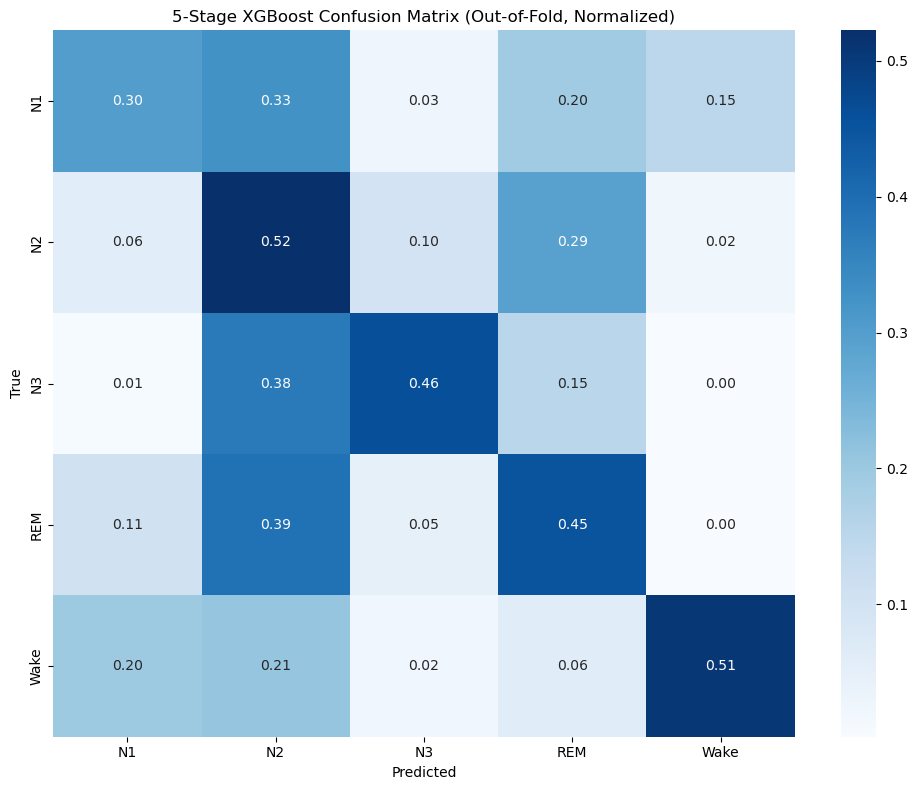

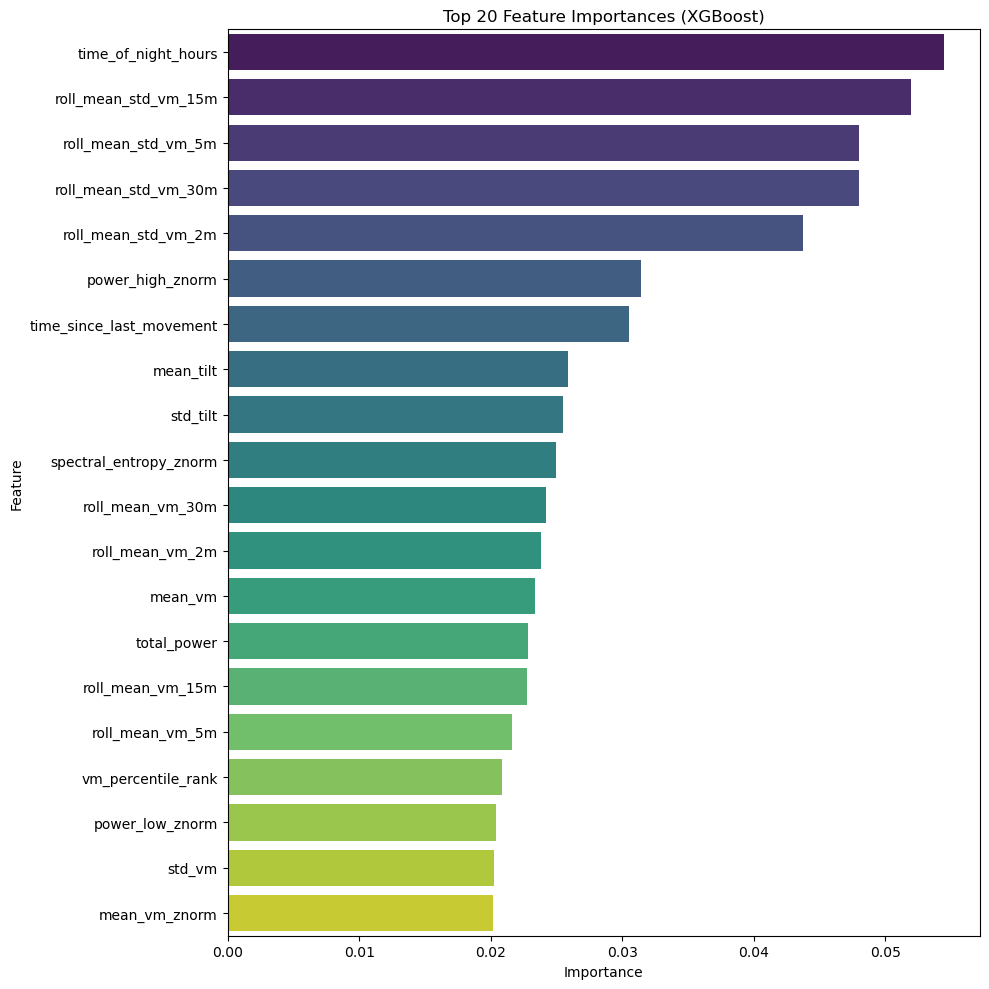


Top 10 features by importance:
                 Feature  Importance
     time_of_night_hours    0.054488
    roll_mean_std_vm_15m    0.051948
     roll_mean_std_vm_5m    0.048015
    roll_mean_std_vm_30m    0.047980
     roll_mean_std_vm_2m    0.043787
        power_high_znorm    0.031427
time_since_last_movement    0.030556
               mean_tilt    0.025905
                std_tilt    0.025510
  spectral_entropy_znorm    0.024964

5-Stage XGBoost Out-of-Fold Summary (LOSO)
  Accuracy : 48.20%
  Macro F1 : 0.4501  95% CI [0.4430, 0.4571]
  Kappa    : 0.2540  95% CI [0.2459, 0.2634]
  McNemar p: 8.23e-04

PER-SUBJECT PERFORMANCE (mean ± SD across subjects)
  Macro F1 : 0.414 ± 0.076  (range 0.290–0.566)
  Cohen's κ: 0.243 ± 0.094  (range 0.047–0.418)
  Accuracy : 0.472 ± 0.087  (range 0.278–0.632)


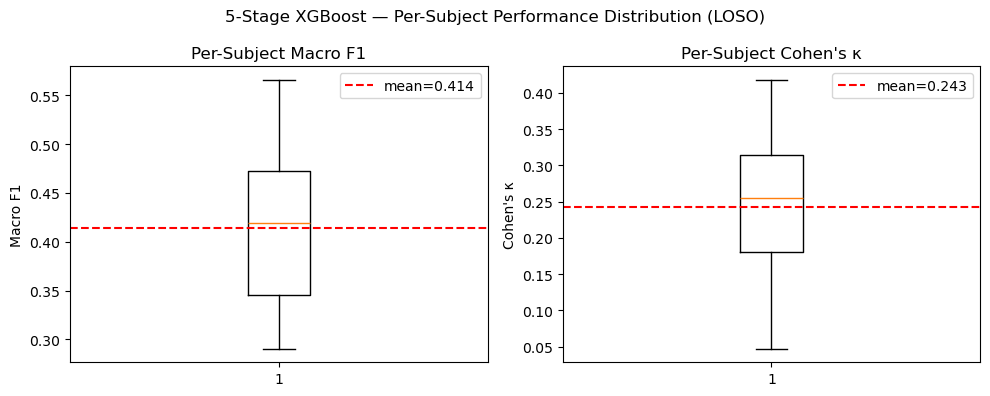

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, roc_auc_score, f1_score)
from statsmodels.stats.contingency_tables import mcnemar

# --- 6.A Classification Report ---
print("5-Stage XGBoost — Out-of-Fold Evaluation (LOSO)\n")
print(classification_report(y_arr, y_pred_final))

kappa = cohen_kappa_score(y_arr, y_pred_final)
macro_f1 = f1_score(y_arr, y_pred_final, average='macro')
accuracy = np.mean(y_arr == y_pred_final)

# --- 6.B Baseline Comparison Table ---
print("=" * 55)
print(f"{'Metric':<20} {'ZeroR Baseline':>15} {'XGB Model':>15}")
print("-" * 55)
print(f"{'Macro F1':<20} {baseline_f1:>15.4f} {macro_f1:>15.4f}")
print(f"{'Cohen Kappa':<20} {baseline_kappa:>15.4f} {kappa:>15.4f}")
print(f"{'Accuracy':<20} {np.mean(y_arr == majority_class):>15.2%} {accuracy:>15.2%}")
print("=" * 55)

# --- 6.C Bootstrap 95% Confidence Intervals ---
print("\nBootstrap 95% CI (n=1,000 resamples)...")
rng = np.random.default_rng(42)
n = len(y_arr)
boot_f1    = np.empty(1000)
boot_kappa = np.empty(1000)
for i in range(1000):
    idx = rng.integers(0, n, size=n)
    boot_f1[i]    = f1_score(y_arr[idx], y_pred_final[idx], average='macro', zero_division=0)
    boot_kappa[i] = cohen_kappa_score(y_arr[idx], y_pred_final[idx])

ci_f1_lo,    ci_f1_hi    = np.percentile(boot_f1,    [2.5, 97.5])
ci_kappa_lo, ci_kappa_hi = np.percentile(boot_kappa, [2.5, 97.5])
print(f"  Macro F1 : {macro_f1:.4f}  95% CI [{ci_f1_lo:.4f}, {ci_f1_hi:.4f}]")
print(f"  Kappa    : {kappa:.4f}  95% CI [{ci_kappa_lo:.4f}, {ci_kappa_hi:.4f}]")

# --- 6.D McNemar's Test (XGBoost vs ZeroR Baseline) ---
xgb_correct      = (y_arr == y_pred_final).astype(int)
baseline_correct = (y_arr == majority_class).astype(int)
b = np.sum((xgb_correct == 1) & (baseline_correct == 0))  # XGB right, baseline wrong
c = np.sum((xgb_correct == 0) & (baseline_correct == 1))  # XGB wrong, baseline right
table = [[0, b], [c, 0]]
mcnemar_result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's test (XGB vs ZeroR): chi2={mcnemar_result.statistic:.2f}, p={mcnemar_result.pvalue:.2e}")
if mcnemar_result.pvalue < 0.05:
    print("  -> XGB error distribution is SIGNIFICANTLY different from ZeroR (p < 0.05)")
else:
    print("  -> No significant difference from ZeroR (p >= 0.05)")

# --- 6.E Per-Class AUC-ROC ---
print("\nPer-Class AUC-ROC (One-vs-Rest):")
for i, cls in enumerate(classes):
    y_bin = (y_arr == cls).astype(int)
    auc = roc_auc_score(y_bin, oof_probs[:, i])
    print(f"  AUC ({cls:>4}): {auc:.4f}")

# --- 6.F Confusion Matrix ---
cm = confusion_matrix(y_arr, y_pred_final, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('5-Stage XGBoost Confusion Matrix (Out-of-Fold, Normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# --- 6.G Feature Importances ---
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=fi_df.head(20),
            palette='viridis', legend=False)
plt.title('Top 20 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
print(fi_df.head(10).to_string(index=False))

# --- 6.H Summary ---
print(f"\n{'='*55}")
print("5-Stage XGBoost Out-of-Fold Summary (LOSO)")
print(f"{'='*55}")
print(f"  Accuracy : {accuracy:.2%}")
print(f"  Macro F1 : {macro_f1:.4f}  95% CI [{ci_f1_lo:.4f}, {ci_f1_hi:.4f}]")
print(f"  Kappa    : {kappa:.4f}  95% CI [{ci_kappa_lo:.4f}, {ci_kappa_hi:.4f}]")
print(f"  McNemar p: {mcnemar_result.pvalue:.2e}")
print(f"{'='*55}")

# --- 6.I Per-Subject Performance (mean ± SD) ---
# Computes per-subject metrics across all 31 LOSO subjects.
# Mean ± SD reported as required by clinical ML reviewers.
print(f"\n{'='*55}")
print("PER-SUBJECT PERFORMANCE (mean ± SD across subjects)")
print(f"{'='*55}")
subj_ids_unique = np.unique(subject_ids_array)
subj_f1s, subj_kappas, subj_accs = [], [], []
for sid in subj_ids_unique:
    mask = subject_ids_array == sid
    s_true, s_pred = y_arr[mask], y_pred_final[mask]
    subj_f1s.append(f1_score(s_true, s_pred, average='macro', zero_division=0))
    subj_kappas.append(cohen_kappa_score(s_true, s_pred))
    subj_accs.append(np.mean(s_true == s_pred))

print(f"  Macro F1 : {np.mean(subj_f1s):.3f} ± {np.std(subj_f1s):.3f}  "
      f"(range {np.min(subj_f1s):.3f}–{np.max(subj_f1s):.3f})")
print(f"  Cohen's κ: {np.mean(subj_kappas):.3f} ± {np.std(subj_kappas):.3f}  "
      f"(range {np.min(subj_kappas):.3f}–{np.max(subj_kappas):.3f})")
print(f"  Accuracy : {np.mean(subj_accs):.3f} ± {np.std(subj_accs):.3f}  "
      f"(range {np.min(subj_accs):.3f}–{np.max(subj_accs):.3f})")
print(f"{'='*55}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(subj_f1s, vert=True)
axes[0].set_title('Per-Subject Macro F1')
axes[0].set_ylabel('Macro F1')
axes[0].axhline(np.mean(subj_f1s), color='r', linestyle='--',
                label=f'mean={np.mean(subj_f1s):.3f}')
axes[0].legend()
axes[1].boxplot(subj_kappas, vert=True)
axes[1].set_title("Per-Subject Cohen's κ")
axes[1].set_ylabel("Cohen's κ")
axes[1].axhline(np.mean(subj_kappas), color='r', linestyle='--',
                label=f'mean={np.mean(subj_kappas):.3f}')
axes[1].legend()
plt.suptitle('5-Stage XGBoost — Per-Subject Performance Distribution (LOSO)')
plt.tight_layout()
plt.show()

## 7. Per-Subject Performance Breakdown

To assess variability across individuals, we compute F1 Macro for each subject and report mean and standard deviation. This validates whether "patient calibration" helps uniformly or benefits some subjects more than others.

In [8]:
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt

subject_stats = []
for sid in sorted(epoch_df['subject_id'].unique()):
    mask = (epoch_df['subject_id'] == sid).values
    if mask.sum() == 0:
        continue
    y_true_s = y.values[mask] if hasattr(y, 'values') else y[mask]
    y_pred_s = y_pred_final[mask]
    f1_per_class = f1_score(y_true_s, y_pred_s, average=None,
                             labels=classes, zero_division=0)
    f1_macro = f1_score(y_true_s, y_pred_s, average='macro', zero_division=0)
    subject_stats.append({
        'subject_id': sid, 'n_epochs': mask.sum(),
        'f1_macro': f1_macro,
        **{f'f1_{cls}': f1_per_class[i] for i, cls in enumerate(classes)}
    })

subject_df = pd.DataFrame(subject_stats)
print(f"Per-Subject F1 Macro: {subject_df['f1_macro'].mean():.4f} +/- {subject_df['f1_macro'].std():.4f}")
print(f"  Min: {subject_df['f1_macro'].min():.4f}  Max: {subject_df['f1_macro'].max():.4f}")
print()
print(subject_df[['subject_id', 'f1_macro'] + [f'f1_{c}' for c in classes]].to_string(index=False))

Per-Subject F1 Macro: 0.4140 +/- 0.0770
  Min: 0.2904  Max: 0.5659

subject_id  f1_macro    f1_N1    f1_N2    f1_N3   f1_REM  f1_Wake
   1066528  0.343536 0.298343 0.384106 0.494505 0.065476 0.475248
   1360686  0.534433 0.283465 0.675214 0.585938 0.583333 0.544218
   1449548  0.374654 0.273504 0.615842 0.565737 0.105263 0.312925
   1455390  0.340648 0.181818 0.764165 0.000000 0.535032 0.222222
   1818471  0.371799 0.200913 0.475870 0.598131 0.298368 0.285714
   2598705  0.341147 0.229508 0.174326 0.649351 0.360882 0.291667
   2638030  0.509338 0.202247 0.515413 0.720721 0.336879 0.771429
   3509524  0.315384 0.150000 0.478632 0.324910 0.000000 0.623377
   3997827  0.523484 0.283019 0.542125 0.607930 0.517680 0.666667
   4018081  0.365904 0.093023 0.631579 0.350427 0.000000 0.754491
   4314139  0.469743 0.380368 0.519182 0.425000 0.483283 0.540881
   4426783  0.444931 0.206452 0.542169 0.360656 0.460411 0.654971
     46343  0.419544 0.250000 0.446927 0.750000 0.000000 0.650794
   51324

## 8. Hypnogram Visualization

Compare predicted vs. true sleep staging for one example subject. Hypnograms are the standard visualization in sleep medicine and provide intuitive assessment of temporal prediction accuracy.

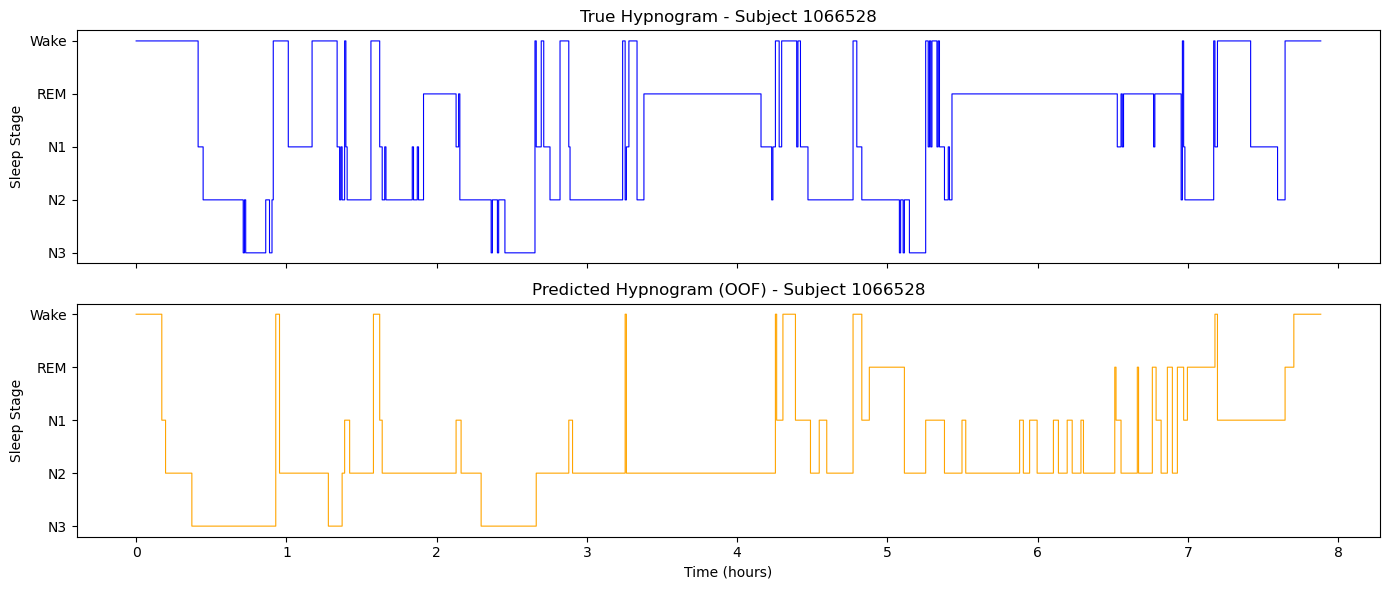

In [9]:
import matplotlib.pyplot as plt

# Pick the first subject deterministically
example_subject = sorted(epoch_df['subject_id'].unique())[0]
mask = (epoch_df['subject_id'] == example_subject).values

epochs = epoch_df.loc[mask, 'epoch_start'].values
y_true_subj = y.values[mask] if hasattr(y, 'values') else y[mask]
y_pred_subj = y_pred_final[mask]

stage_order = {'Wake': 4, 'REM': 3, 'N1': 2, 'N2': 1, 'N3': 0}
ytick_labels = ['N3', 'N2', 'N1', 'REM', 'Wake']

true_numeric = [stage_order[s] for s in y_true_subj]
pred_numeric = [stage_order[s] for s in y_pred_subj]

hours = (epochs - epochs[0]) / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].step(hours, true_numeric, where='mid', color='blue', linewidth=0.8)
axes[0].set_yticks(range(len(ytick_labels)))
axes[0].set_yticklabels(ytick_labels)
axes[0].set_title(f'True Hypnogram - Subject {example_subject}')
axes[0].set_ylabel('Sleep Stage')

axes[1].step(hours, pred_numeric, where='mid', color='orange', linewidth=0.8)
axes[1].set_yticks(range(len(ytick_labels)))
axes[1].set_yticklabels(ytick_labels)
axes[1].set_title(f'Predicted Hypnogram (OOF) - Subject {example_subject}')
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Sleep Stage')

plt.tight_layout()
plt.show()